#### Research question: "Which weather factors (temperature, humidity, wind, rainfall) most strongly drive daily electricity demand, and how much of demand can weather explain?"
Since my research question is about daily electricity demand, I merged the data by date instead of the full timestamp. The time of day isn't really relevant to my question as I only care about how a whole day's weather relates to that day's demand and not how demand changes hour to hour. 

In [24]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("model_data.csv")

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34506 entries, 0 to 34505
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   state          34506 non-null  object 
 1   date           34506 non-null  object 
 2   max_temp       34506 non-null  float64
 3   mean_temp      34506 non-null  float64
 4   min_temp       34506 non-null  float64
 5   max_dew        34506 non-null  float64
 6   mean_dew       34506 non-null  float64
 7   min_dew        34506 non-null  float64
 8   max_wet_bulb   34501 non-null  float64
 9   mean_wet_bulb  34501 non-null  float64
 10  min_wet_bulb   34501 non-null  float64
 11  max_humidity   34506 non-null  float64
 12  mean_humidity  34506 non-null  float64
 13  min_humidity   34506 non-null  float64
 14  max_wind       25869 non-null  float64
 15  mean_wind      25869 non-null  float64
 16  min_wind       25869 non-null  float64
 17  max_gust       25848 non-null  float64
 18  mean_g

In [26]:
df.describe() # ensure there are no unrealistic values

,max_temp,mean_temp,min_temp,max_dew,mean_dew,min_dew,max_wet_bulb,mean_wet_bulb,min_wet_bulb,max_humidity,...,max_gust,mean_gust,min_gust,max_pressure,mean_pressure,min_pressure,total_rain,peak_demand,mean_demand,mean_price
count,34506.000000,34506.000000,34506.000000,34506.000000,34506.000000,34506.000000,34501.000000,34501.000000,34501.000000,34506.000000,...,25848.000000,25848.000000,25848.000000,34501.000000,34501.000000,34501.000000,34498.000000,34506.000000,34506.000000,34506.000000
mean,22.171390,17.312894,13.079137,12.788225,9.872392,6.791810,15.837721,13.457937,11.032851,84.639106,...,33.571936,17.741868,4.583341,1019.584421,1016.590561,1013.733132,2.874619,5435.223094,4620.322108,51.475346
std,6.040272,5.208603,5.013202,4.895511,5.205458,5.958956,4.343416,4.386079,4.644535,10.923192,...,13.919259,8.405632,4.946576,6.632509,7.224821,7.930462,8.380684,3261.227805,2767.841562,77.018919
min,6.200000,3.493750,-0.300000,-5.800000,-9.316000,-39.200000,3.300000,1.937037,-0.900000,17.000000,...,0.000000,0.000000,0.000000,987.000000,983.178947,975.300000,0.000000,928.290000,772.840625,-182.918542
25%,17.500000,13.281250,9.300000,9.100000,5.931088,2.600000,12.400000,10.025000,7.500000,79.000000,...,24.100000,11.931091,0.000000,1015.300000,1012.042857,1008.800000,0.000000,1705.315000,1416.169271,25.632344
50%,21.900000,16.989583,12.700000,12.400000,9.244215,6.100000,15.600000,13.029167,10.500000,87.000000,...,31.300000,15.831250,3.600000,1019.700000,1016.845833,1014.200000,0.000000,6225.548335,5369.563299,35.778229
75%,26.300000,21.170833,16.800000,16.400000,13.648714,11.000000,19.200000,16.750000,14.400000,93.000000,...,38.900000,21.270833,7.600000,1024.000000,1021.389583,1019.100000,2.000000,7539.747500,6398.848021,57.644896
max,47.400000,38.875000,34.100000,41.000000,24.660417,23.400000,41.000000,26.800000,26.000000,123.000000,...,129.600000,71.868421,42.500000,1041.800000,1040.029167,1038.100000,182.600000,14579.860000,11539.817500,3377.320417


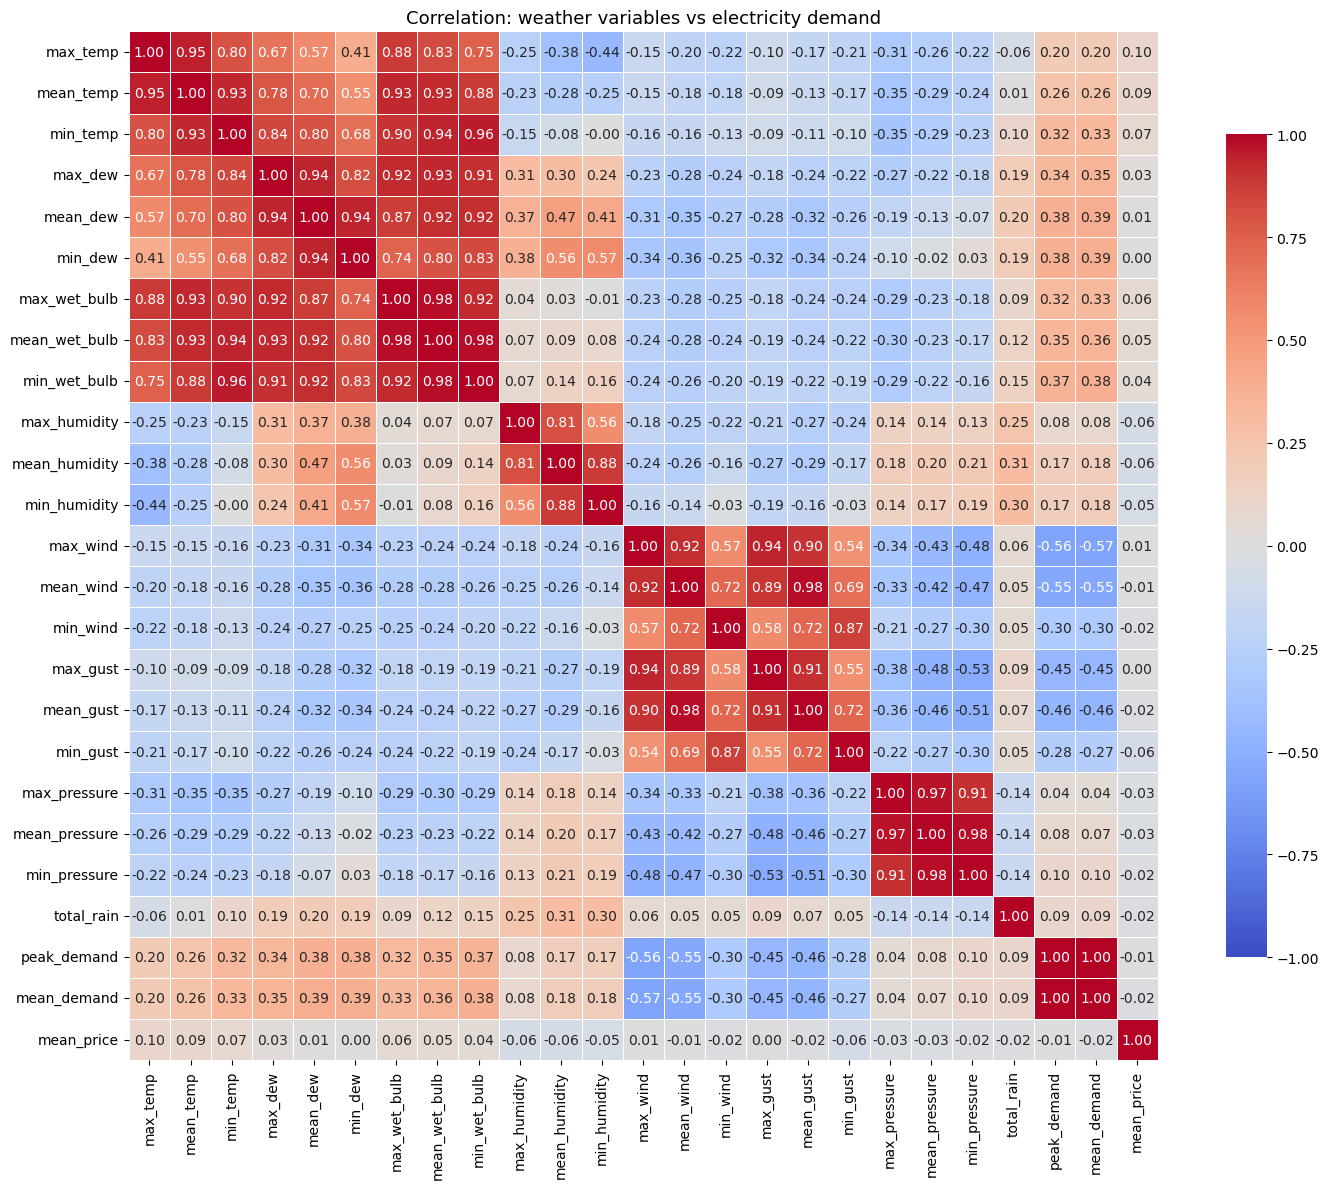

In [27]:
# Correlation on the numeric columns
corr = df.corr(numeric_only=True)

plt.figure(figsize=(15, 12))
sns.heatmap(
    corr,
    annot=True,          # write the number in each cell
    fmt=".2f",           # 2 decimal places
    cmap="coolwarm",     # red = positive, blue = negative
    center=0,            # 0 correlation = white
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation: weather variables vs electricity demand", fontsize=13)
plt.tight_layout()
plt.show()

In [28]:
df.isnull().sum() # Checks for NaN as a value

state               0
date                0
max_temp            0
mean_temp           0
min_temp            0
max_dew             0
mean_dew            0
min_dew             0
max_wet_bulb        5
mean_wet_bulb       5
min_wet_bulb        5
max_humidity        0
mean_humidity       0
min_humidity        0
max_wind         8637
mean_wind        8637
min_wind         8637
max_gust         8658
mean_gust        8658
min_gust         8658
max_pressure        5
mean_pressure       5
min_pressure        5
total_rain          8
peak_demand         0
mean_demand         0
mean_price          0
dtype: int64

Peak and mean demand is pretty much the same, so ill use peak as my target, because my research question focuses on how weather drives/pushes demand

For my variables/features, i will use max_temp, mean_humidity, mean_wind, total_rain, mean_pressure

I will choose mean_temp over max/min as average temperatures matter more. 
- A short burst of 35C weather might not cause a lot of energy demand as it might not have lasted long enough for people to increase electricity usage (air-conditioning). 
- A short burst of high temperature weather might also not affect energy usage if the burst occured during the afternoon and people were at work where air-conditioning is kept on regardless of medium/high temperatures.
- This means that when they get home, the short burst of high temperature weather might have ended, resulting in them not needing air conditioning
- A day with a high mean_temp is able to identify/outline days where people would use energy both at work, and when they get home.
- The same is true for cold days and heating

Comment made after modelling.
- After comparing using both mean_temp and max_temp, mean_temp gave a higher R2 score which confirms my above statement about it being a more accurate predictor in electricity demand

Only 25869/34506 of rows have wind and gust as a value (roughly 74%). 
- This means that i will have to choose between dropping wind as a variable, or delete the rows that do not have wind
- As both wind and gust are seen as a big correlator with demand (even more than temp), i will drop the rows without wind in order to keep it as a variable

In [29]:
df = df.dropna()

In [30]:
df.describe()

,max_temp,mean_temp,min_temp,max_dew,mean_dew,min_dew,max_wet_bulb,mean_wet_bulb,min_wet_bulb,max_humidity,...,max_gust,mean_gust,min_gust,max_pressure,mean_pressure,min_pressure,total_rain,peak_demand,mean_demand,mean_price
count,25839.000000,25839.000000,25839.000000,25839.000000,25839.000000,25839.000000,25839.000000,25839.000000,25839.000000,25839.000000,...,25839.000000,25839.000000,25839.000000,25839.000000,25839.000000,25839.000000,25839.000000,25839.000000,25839.000000,25839.000000
mean,22.065208,17.059596,12.623643,12.417628,9.429794,6.279566,15.579260,13.128180,10.609679,84.806610,...,33.571589,17.741599,4.582786,1019.427981,1016.418970,1013.524177,2.554031,4131.301076,3515.930758,53.110335
std,6.410571,5.445915,5.096738,4.888759,5.133292,5.880694,4.462462,4.434424,4.638365,11.093605,...,13.920720,8.406680,4.946475,6.748581,7.361541,8.100151,7.718506,2556.252291,2203.641810,81.282098
min,6.200000,3.493750,-0.300000,-5.800000,-9.316000,-39.200000,3.300000,1.937037,-0.900000,17.000000,...,0.000000,0.000000,0.000000,987.000000,983.178947,975.300000,0.000000,928.290000,772.840625,-182.918542
25%,16.900000,12.871875,8.900000,8.800000,5.641225,2.300000,12.100000,9.727003,7.200000,79.000000,...,24.100000,11.929448,0.000000,1015.200000,1011.879414,1008.600000,0.000000,1553.860000,1284.898646,25.957708
50%,21.700000,16.583333,12.200000,11.900000,8.687500,5.500000,15.200000,12.624194,10.000000,87.000000,...,31.300000,15.831250,3.600000,1019.600000,1016.731111,1014.100000,0.000000,4973.865000,4325.957083,36.892083
75%,26.700000,20.985417,16.100000,15.800000,12.751042,10.000000,18.900000,16.202083,13.600000,93.000000,...,38.900000,21.270833,7.600000,1023.900000,1021.281250,1018.900000,1.800000,6601.485000,5681.331232,60.379688
max,47.400000,38.875000,34.100000,41.000000,24.660417,23.000000,41.000000,26.466667,25.000000,123.000000,...,129.600000,71.868421,42.500000,1041.800000,1040.029167,1038.100000,182.600000,10414.860000,8425.077708,3377.320417


Since low temperatures and high temperatures usually warrant more energy usage, a U shaped curve is created when plotting Temperatures against Energy demand. 
- To account for this, i will investigate into what temperatures people are comfortable with (temperatures that have the least energy demand), and create a new feature called 'temp_discomfort' from it
- This allows me to use general comfortability as a feature instead of just pure temperature

<Axes: xlabel='mean_temp', ylabel='peak_demand'>

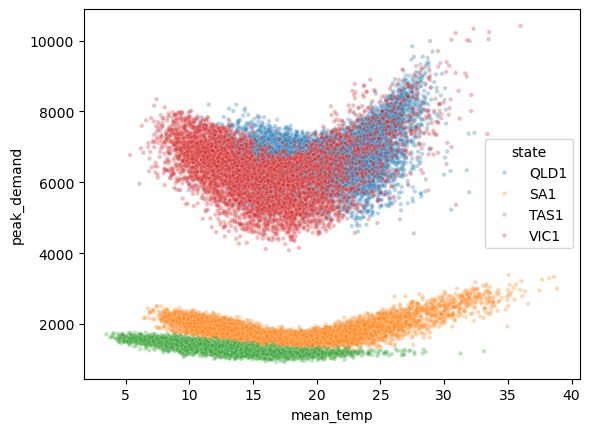

In [31]:
sns.scatterplot(data=df, x='mean_temp', y='peak_demand', hue='state', alpha=0.3, s=10)

Here i can see that energy demand varies widely among different states due to the differences in population, economies and size.
- In order to overcome this, i will have to normalise the demand by dividing demand with the state's daily average 'peak_demand' to give a gauge on how much more energy is used on a specific day due to the weather
- This is better than dividing by population, as the population of these states have changed over the years, and would require a separate data source.
- Dividing by population also assumes that population is the only factor in  this gap. (some states have more malls/public areas per capita)
- In this 'demand_relative' feature, a value of 1 would mean that that day's energy demand is the average of the state, and 1.3 would be 30% higher than the state average demand
- This 'demand_relative' feature will be the new target(y)

In [32]:
df['demand_relative'] = df['peak_demand'] / df.groupby('state')['peak_demand'].transform('mean')
df['demand_relative'].describe()

count    25839.000000
mean         1.000000
std          0.132674
min          0.645085
25%          0.907073
50%          0.990738
75%          1.078708
max          1.891536
Name: demand_relative, dtype: float64

<Axes: xlabel='mean_temp', ylabel='demand_relative'>

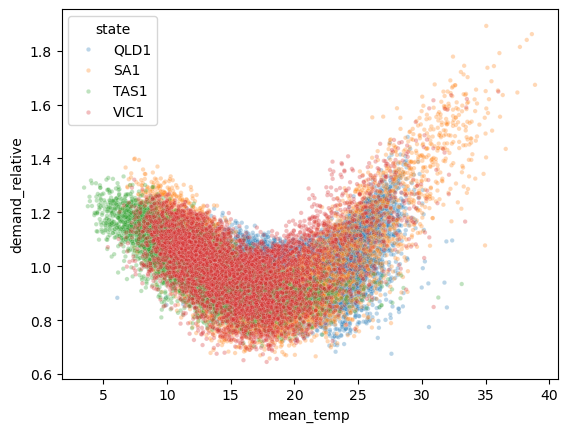

In [33]:
sns.scatterplot(data=df, x='mean_temp', y='demand_relative', hue='state', alpha=0.3, s=10)

Here ill start to create the 'comfort_point' variable (temperature where energy demand is the lowest) 

Ill also create a 'temp_discomfort' feature which will be how many degreees difference a specific row is from the comfort point

In [34]:
demand_by_temp = df.groupby(df['mean_temp'].round())['demand_relative'].mean()
demand_by_temp.idxmin()   # the temperature with the lowest average demand

np.float64(18.0)

In [35]:
comfort_point = demand_by_temp.idxmin() # A discomfort point of 0 is the point/temp of least energy usage

df['temp_discomfort'] = (df['mean_temp'] - comfort_point).abs() # Calculates how far each row's max temp is from the comfort zone
print(comfort_point)

18.0


My original plan was to use 'temp_discomfort' as a gauge of how far that day's peak temperature was from the comfort point.

However, hot days are usually more uncomfortable than cold days, even if they are the same difference from the comfort point (14C vs 34C degree weather)
- To overcome this, i will split the 'temp_discomfort' feature into 2 ('heat_discomfort' and 'cold_discomfort')
- This will allow the model to take into consideration of how warmer days('heat_discomfort') and colder days ('cold_discomfort') affect 'peak_demand' differently and ill be able to get 2 different co-efficients from them


In [36]:
df['heat_discomfort'] = (df['mean_temp'] - comfort_point).clip(lower=0)   # 0 if below comfort
df['cold_discomfort'] = (comfort_point - df['mean_temp']).clip(lower=0)   # 0 if above comfort

In [37]:
df.isnull().sum() # Checks for NaN as a value

state              0
date               0
max_temp           0
mean_temp          0
min_temp           0
max_dew            0
mean_dew           0
min_dew            0
max_wet_bulb       0
mean_wet_bulb      0
min_wet_bulb       0
max_humidity       0
mean_humidity      0
min_humidity       0
max_wind           0
mean_wind          0
min_wind           0
max_gust           0
mean_gust          0
min_gust           0
max_pressure       0
mean_pressure      0
min_pressure       0
total_rain         0
peak_demand        0
mean_demand        0
mean_price         0
demand_relative    0
temp_discomfort    0
heat_discomfort    0
cold_discomfort    0
dtype: int64

### Linear model fitting
- In this section i will use a regression model to answer "Which weather factors (temperature, humidity, wind, rainfall) most strongly drive daily electricity demand?", the first part of my research question
- I will use a linear model as the coefficients are easy to interpret

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error, r2_score)
from sklearn.preprocessing import StandardScaler

X = df[['heat_discomfort', 'cold_discomfort', 'mean_dew',
        'mean_wind', 'total_rain', 'mean_pressure']]

y = df['demand_relative']

X_train_lin, X_test_lin, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_lin = StandardScaler()
X_train_lin = scaler_lin.fit_transform(X_train_lin)
X_test_lin  = scaler_lin.transform(X_test_lin)

model = LinearRegression()
model.fit(X_train_lin, y_train)
y_pred_lin = model.predict(X_test_lin)

print('MAE :', mean_absolute_error(y_test, y_pred_lin))
print('RMSE:', root_mean_squared_error(y_test, y_pred_lin))
print()
print("Train R²:", model.score(X_train_lin, y_train))
print("Test R²:", model.score(X_test_lin, y_test))

MAE : 0.07550556435076136
RMSE: 0.09562578813519149

Train R²: 0.4820352109872267
Test R²: 0.47804263099942823


In [68]:
coefficients = pd.Series(model.coef_, index=X.columns)
print(coefficients.sort_values(key=abs, ascending=False))

heat_discomfort    0.096375
cold_discomfort    0.087625
mean_wind         -0.022569
mean_dew          -0.010401
total_rain         0.001833
mean_pressure      0.001002
dtype: float64


### Addressing wind's coefficients
Wind is negative but weak (−0.022). Wind had a 0.55 correlation, but in the full model, controlling for temperature, its effect shrinks to −0.022. This is exactly the "correlation vs effect" distinction in action. Wind's strong raw correlation was largely temperature in disguise (calm days are hot days). Once temperature is accounted for, wind's genuine independent contribution is small. That's a textbook demonstration of why multiple regression beats eyeballing correlations — and it's worth highlighting in your writeup as a real insight.

In [18]:
df[['mean_wind', 'heat_discomfort', 'cold_discomfort']].corr()

,mean_wind,heat_discomfort,cold_discomfort
mean_wind,1.000000,-0.117088,0.190384
heat_discomfort,-0.117088,1.000000,-0.518223
cold_discomfort,0.190384,-0.518223,1.000000


Wind had a notable raw correlation with demand, but this was largely because windy days tend to be cooler (wind correlates more with cold conditions than hot). Once temperature was accounted for via the discomfort features, wind's independent effect was small — it acts mostly as an indirect indicator of temperature conditions rather than a direct driver of demand

### Addressing dew's coefficients

Dew point was investigated as a measure of atmospheric moisture, as higher moisture theoretically increases cooling demand (air-conditioners must work harder to dehumidify). 

However, dew point produced a negative coefficient in the model, and further investigation showed this reflects a genuine negative correlation between dew point and demand in the data. 

This negative relationship is largely explained by dew point's strong correlation with temperature (0.68). Because dew point and temperature move closely together, much of dew point's relationship with demand overlaps with temperature's own effect, making its independent contribution difficult to isolate. 

In [19]:
df[['mean_dew', 'demand_relative']].corr()

,mean_dew,demand_relative
mean_dew,1.000000,-0.036413
demand_relative,-0.036413,1.000000


In [20]:
df[['mean_dew', 'mean_temp']].corr()

,mean_dew,mean_temp
mean_dew,1.000000,0.685119
mean_temp,0.685119,1.000000


In [21]:
print("Intercept:", model.intercept_)
print("Coefficients:")
for name, coef in zip(X.columns, model.coef_):
    print(f"  {name}: {coef}")

Intercept: 0.9998560638199051
Coefficients:
  heat_discomfort: 0.09637468031182404
  cold_discomfort: 0.08762471659136306
  mean_dew: -0.010400545627239424
  mean_wind: -0.0225691476786037
  total_rain: 0.001833221752526423
  mean_pressure: 0.001001604603531937


### Polyniomial fitting
- In this section I will use a polynomial fitting to answer "how much of demand can weather explain?", the second part of my research question

In [70]:
X = df[['heat_discomfort', 'cold_discomfort', 'mean_dew',
        'mean_wind', 'total_rain', 'mean_pressure']]

y = df['demand_relative']

X_train_poly_base, X_test_poly_base, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_poly = StandardScaler()
X_train_scaled = scaler_poly.fit_transform(X_train_poly_base)
X_test_scaled  = scaler_poly.transform(X_test_poly_base)

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly  = poly.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

print('MAE :', mean_absolute_error(y_test, y_pred_poly))
print('RMSE:', root_mean_squared_error(y_test, y_pred_poly))
print()
print("Train R²:", poly_model.score(X_train_poly, y_train))
print("Test R²:", poly_model.score(X_test_poly, y_test))

MAE : 0.0724119530777427
RMSE: 0.09184845380755212

Train R²: 0.5293024588912638
Test R²: 0.5184640922933172


In [23]:
# Finish notes/comments
# Create an additional polynomial model where raw temperatures are used and the U shaped curve is kept
# Create conclusion and present findings of value